In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from itertools import combinations
from collections import defaultdict

## 1. Load shared resources

- **Protein index** — row/column order shared by all matrices  
- **Proteomics data** — raw abundance profiles for profile plots  
- **CORUM positive pairs** — ground-truth co-complex labels  
- **Overlap matrix** — shared observed patients per pair  

In [2]:
# ── Protein index (column name differs by directory; use first column) ──
_idx_df  = pd.read_csv("../outputs/similarity_correlation/protein_index.csv")
proteins = _idx_df.iloc[:, 0].tolist()
protein_to_idx = {p: i for i, p in enumerate(proteins)}
print(f"Proteins: {len(proteins)}")

# ── Raw abundance profiles (proteins × patients) ──
expr_df = pd.read_csv("../data/processed/proteomics_data_processed.csv", index_col=0)
print(f"Expression matrix: {expr_df.shape[0]} proteins × {expr_df.shape[1]} patients")

# ── Overlap matrix (shared observed patients) ──
overlap = np.load("../data/processed/protein_overlap.npy").astype(np.float32)
np.fill_diagonal(overlap, np.nan)
print(f"Overlap matrix: {overlap.shape}")

# ── CORUM positive pairs → canonical sorted set ──
corum_df = pd.read_csv("../outputs/dataset_overlap/CORUM_positive_pairs_in_proteomics.csv")
corum_set = {
    tuple(sorted([r.protein_1, r.protein_2]))
    for _, r in corum_df.iterrows()
}
# Build lookup: canonical pair → complex names
corum_names = {
    tuple(sorted([r.protein_1, r.protein_2])): r.complex_names
    for _, r in corum_df.iterrows()
    if hasattr(r, "complex_names") and not pd.isna(r.get("complex_names", float("nan")))
}
print(f"CORUM positive pairs: {len(corum_set):,}")

Proteins: 12142
Expression matrix: 12142 proteins × 118 patients
Overlap matrix: (12142, 12142)
CORUM positive pairs: 40,776


## 2. Define similarity methods

In [3]:
METHODS = [
    {"name": "pearson",                  "matrix": "../outputs/similarity_correlation/pearson.npy"},
    {"name": "spearman",                 "matrix": "../outputs/similarity_correlation/spearman.npy"},
    {"name": "pearson_adjusted",         "matrix": "../outputs/similarity_correlation/pearson_adjusted.npy"},
    {"name": "spearman_adjusted",        "matrix": "../outputs/similarity_correlation/spearman_adjusted.npy"},
    {"name": "combined_pearson_jaccard", "matrix": "../outputs/similarity_correlation/combined_pearson_jaccard.npy"},
    {"name": "combined_spearman_jaccard","matrix": "../outputs/similarity_correlation/combined_spearman_jaccard.npy"},
    {"name": "intensity_rbf",            "matrix": "../outputs/similarity_correlation/intensity_rbf.npy"},
    {"name": "composite_rbf_jaccard",    "matrix": "../outputs/similarity_correlation/composite_rbf_jaccard.npy"},
    {"name": "autoencoder_cosine",       "matrix": "../outputs/similarity_autoencoder/autoencoder_cosine.npy"},
    {"name": "transformer_cosine",       "matrix": "../outputs/similarity_transformer/transformer_cosine.npy"},
]

TOP_K = 20  # pairs to retain per method for overlap analysis

## 3. Top 3 pairs per method — full rows

For each method, the upper triangle of the similarity matrix is ranked descending.
Each row shows: rank, protein_1, protein_2, score, shared_patients, corum_label, complex_name.

In [4]:
def top_pairs(sim: np.ndarray, proteins: list, k: int, overlap: np.ndarray,
              corum_set: set, corum_names: dict) -> pd.DataFrame:
    """Extract top-k scored pairs from the upper triangle of a similarity matrix."""
    rows_idx, cols_idx = np.triu_indices(len(proteins), k=1)
    scores = sim[rows_idx, cols_idx]

    valid  = ~np.isnan(scores)
    rows_idx, cols_idx, scores = rows_idx[valid], cols_idx[valid], scores[valid]

    # Partial sort: find top-k indices without sorting everything
    if len(scores) <= k:
        order = np.argsort(scores)[::-1]
    else:
        order = np.argpartition(scores, -k)[-k:]
        order = order[np.argsort(scores[order])[::-1]]

    records = []
    for rank, idx in enumerate(order, start=1):
        i, j   = int(rows_idx[idx]), int(cols_idx[idx])
        p1, p2 = proteins[i], proteins[j]
        pair   = tuple(sorted([p1, p2]))
        shared = int(overlap[i, j]) if not np.isnan(overlap[i, j]) else np.nan
        records.append({
            "rank":           rank,
            "protein_1":      p1,
            "protein_2":      p2,
            "score":          float(scores[idx]),
            "shared_patients": shared,
            "corum_label":    int(pair in corum_set),
            "complex_name":   corum_names.get(pair, ""),
        })
    return pd.DataFrame(records)


all_top = {}  # method_name → full top-k DataFrame

for m in METHODS:
    name = m["name"]
    path = Path(m["matrix"])
    if not path.exists():
        print(f"  SKIP {name} — file not found")
        continue

    sim = np.load(path)
    np.fill_diagonal(sim, np.nan)   # exclude self-pairs
    df  = top_pairs(sim, proteins, TOP_K, overlap, corum_set, corum_names)
    all_top[name] = df

    print(f"\n{'─'*60}")
    print(f"  Method: {name}")
    print(f"{'─'*60}")
    print(df.head(3).to_string(index=False))


────────────────────────────────────────────────────────────
  Method: pearson
────────────────────────────────────────────────────────────
 rank protein_1 protein_2    score  shared_patients  corum_label       complex_name
    1       FGB       FGG 0.996138              118            1 Fibrinogen complex
    2    SPTAN1    SPTBN1 0.994049              118            0                   
    3     SPTA1      SPTB 0.993816              118            0                   

────────────────────────────────────────────────────────────
  Method: spearman
────────────────────────────────────────────────────────────
 rank protein_1 protein_2    score  shared_patients  corum_label       complex_name
    1       FGB       FGG 0.993814              118            1 Fibrinogen complex
    2     SPTA1      SPTB 0.989519              118            0                   
    3    SPTAN1    SPTBN1 0.988788              118            0                   

────────────────────────────────────────────

## 4. Overlap in top-20 pairs across methods

A pair is counted as overlapping if it appears in the top-20 of **at least 2 methods**.
The table shows each such pair, how many methods rank it in top-20, and which methods.

In [7]:
# Map every canonical pair → list of methods that rank it in top-20
pair_to_methods = defaultdict(list)

for method_name, df in all_top.items():
    for _, row in df.iterrows():
        pair = tuple(sorted([row["protein_1"], row["protein_2"]]))
        pair_to_methods[pair].append(method_name)

# Keep only pairs appearing in ≥2 methods
overlap_pairs = {
    pair: methods
    for pair, methods in pair_to_methods.items()
    if len(methods) >= 2
}

# Build summary table
overlap_rows = []
for pair, methods in sorted(overlap_pairs.items(), key=lambda x: -len(x[1])):
    p1, p2 = pair
    corum_label = int(pair in corum_set)
    complex_name = corum_names.get(pair, "")
    # Get score from each method
    scores_by_method = {}
    for m in methods:
        row = all_top[m][all_top[m].apply(
            lambda r: tuple(sorted([r.protein_1, r.protein_2])) == pair, axis=1
        )]
        if len(row) > 0:
            scores_by_method[m] = round(row.iloc[0]["score"], 4)

    overlap_rows.append({
        "protein_1":    p1,
        "protein_2":    p2,
        "n_methods":    len(methods),
        "methods":      ", ".join(methods),
        "corum_label":  corum_label,
        "complex_name": complex_name,
        "scores":       str(scores_by_method),
    })

overlap_df = pd.DataFrame(overlap_rows)

if len(overlap_df) == 0:
    print("No pairs appear in top-20 of more than one method.")
else:
    print(f"Pairs appearing in top-20 of ≥2 methods: {len(overlap_df)}")
    print()
    print(overlap_df.to_string(index=False))

Pairs appearing in top-20 of ≥2 methods: 42

protein_1 protein_2  n_methods                                                                                                                                                                                   methods  corum_label                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                complex_name          

## 5. Protein abundance profiles for overlapping pairs

For each overlapping pair, plot both proteins' abundance profiles across all 118 patients
on the same axis so co-variation is immediately visible.
Patients are sorted by protein_1's abundance to highlight the co-movement.

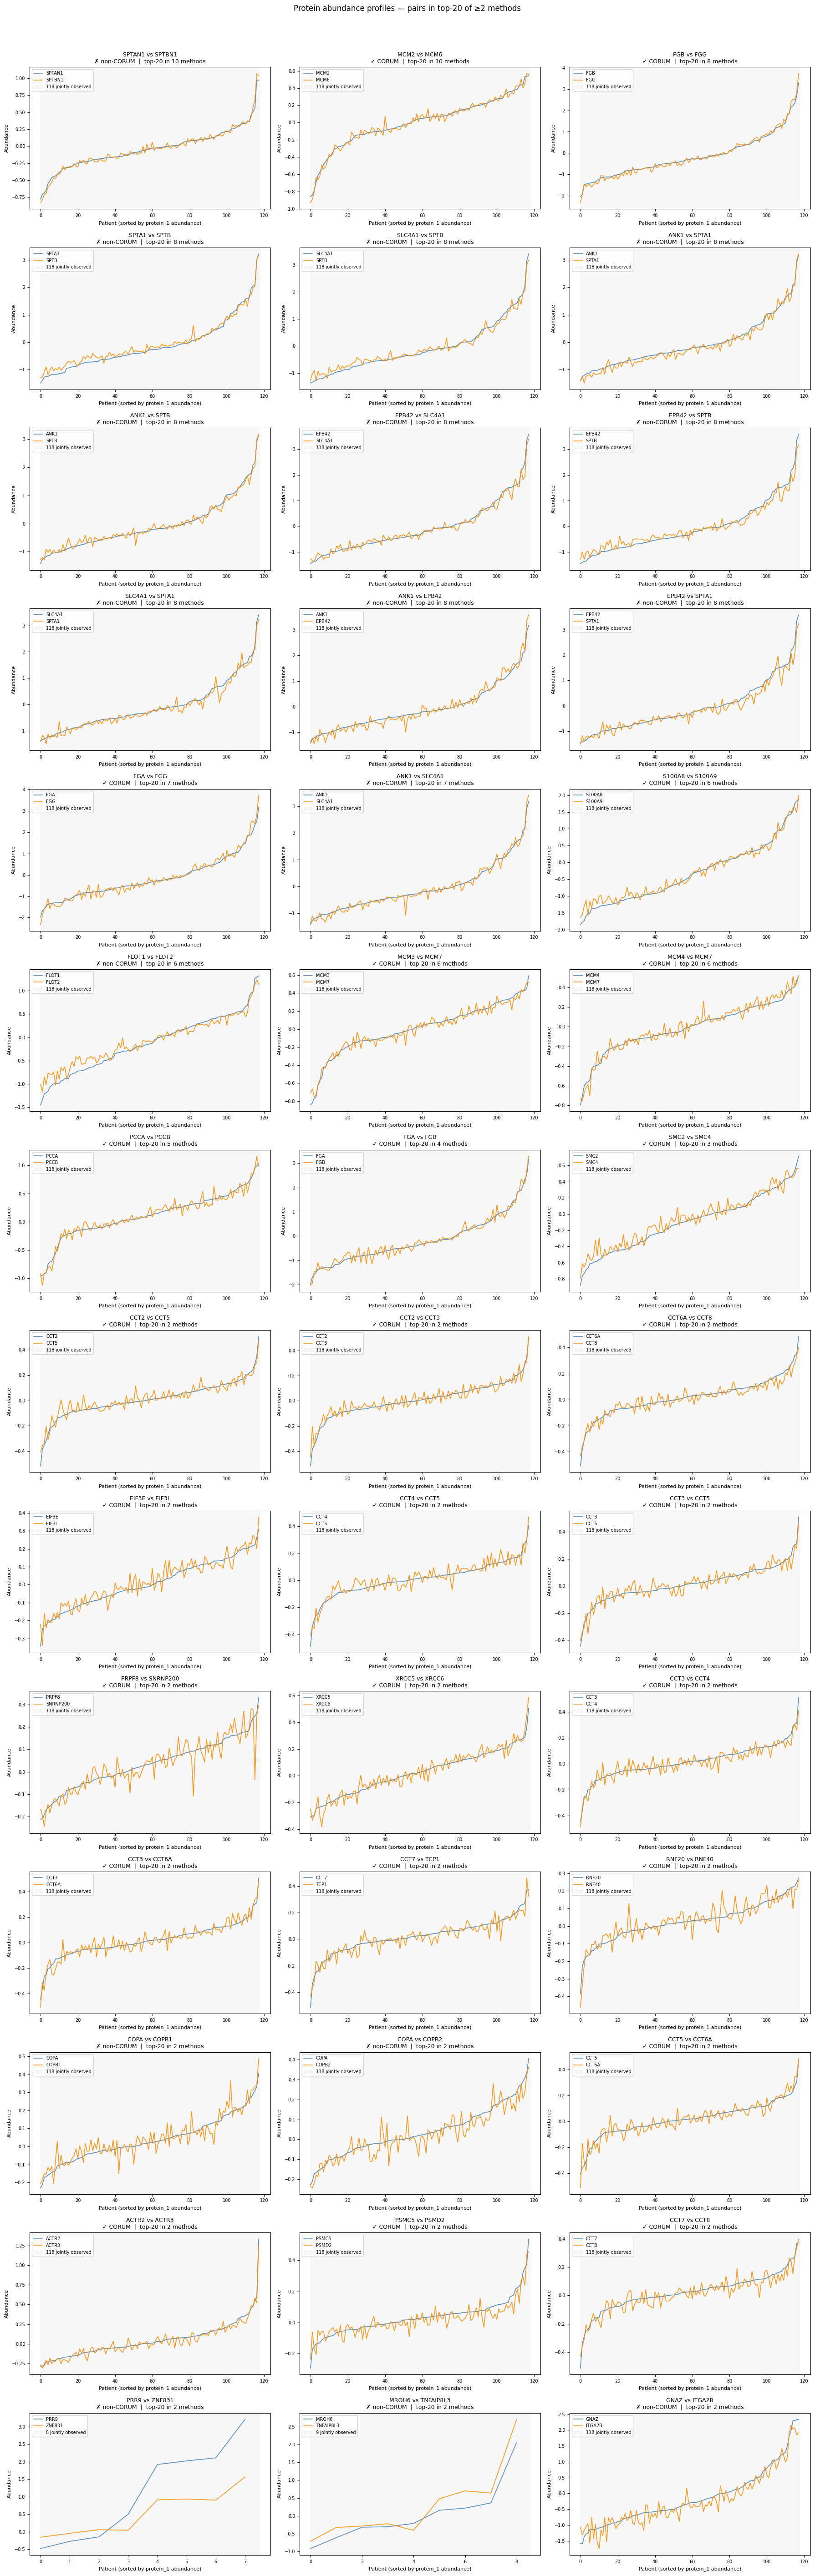

In [6]:
if len(overlap_df) == 0:
    print("No overlapping pairs to plot.")
else:
    n_pairs = len(overlap_df)
    ncols   = min(3, n_pairs)
    nrows   = (n_pairs + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 4 * nrows),
                             squeeze=False)

    patients = expr_df.columns.tolist()

    for ax_idx, (_, row) in enumerate(overlap_df.iterrows()):
        ax  = axes[ax_idx // ncols][ax_idx % ncols]
        p1, p2 = row["protein_1"], row["protein_2"]

        v1 = expr_df.loc[p1].values.astype(float) if p1 in expr_df.index else np.full(len(patients), np.nan)
        v2 = expr_df.loc[p2].values.astype(float) if p2 in expr_df.index else np.full(len(patients), np.nan)

        # Sort patients by protein_1 observed values (NaN to the right)
        obs_mask = ~np.isnan(v1)
        sort_order = np.argsort(np.where(obs_mask, v1, np.inf))
        x  = np.arange(len(patients))
        y1 = v1[sort_order]
        y2 = v2[sort_order]

        ax.plot(x, y1, color="steelblue",  lw=1.2, label=p1, alpha=0.9)
        ax.plot(x, y2, color="darkorange", lw=1.2, label=p2, alpha=0.9)

        # Shade jointly observed region
        joint_obs = ~np.isnan(y1) & ~np.isnan(y2)
        if joint_obs.any():
            ax.axvspan(0, joint_obs.sum() - 0.5, alpha=0.06, color="gray",
                       label=f"{joint_obs.sum()} jointly observed")

        corum_tag = "✓ CORUM" if row["corum_label"] else "✗ non-CORUM"
        n_methods = row["n_methods"]
        ax.set_title(f"{p1} vs {p2}\n{corum_tag}  |  top-20 in {n_methods} methods",
                     fontsize=9)
        ax.set_xlabel("Patient (sorted by protein_1 abundance)", fontsize=8)
        ax.set_ylabel("Abundance", fontsize=8)
        ax.legend(fontsize=7, loc="upper left")
        ax.tick_params(labelsize=7)

    # Hide unused subplots
    for ax_idx in range(n_pairs, nrows * ncols):
        axes[ax_idx // ncols][ax_idx % ncols].set_visible(False)

    plt.suptitle("Protein abundance profiles — pairs in top-20 of ≥2 methods",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig("../outputs/figures/top_pairs_overlap_profiles.png",
                dpi=150, bbox_inches="tight")
    plt.show()